In [1]:
%pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install xgboost

In [51]:
import pandas as pd
import numpy as np


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
#data visualization

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
#model traning

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
#model uses

In [55]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
pd.set_option("display.max_columns", None)

sns.set_theme(style="ticks")

print("Libraries import is successful.")

Libraries import is successful.


In [56]:
import pandas as pd

df = pd.read_csv("Train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [57]:
import pandas as pd

df = pd.read_csv("testdata.csv")
df.head()

,Unnamed: 0,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [58]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Number of rows: 8523
Number of columns: 13

Column Names:
['Unnamed: 0', 'Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']

First 5 Rows:


,Unnamed: 0,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052



Last 5 Rows:


,Unnamed: 0,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [59]:
data_info = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Missing_Values": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique_Values": df.nunique()
})

display(data_info)

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
Unnamed: 0,Unnamed: 0,int64,0,0.00,8523
Item_Identifier,Item_Identifier,object,0,0.00,1559
Item_Weight,Item_Weight,float64,4,0.05,444
Item_Fat_Content,Item_Fat_Content,object,0,0.00,5
Item_Visibility,Item_Visibility,float64,0,0.00,7880
Item_Type,Item_Type,object,0,0.00,16
Item_MRP,Item_MRP,float64,0,0.00,5938
Outlet_Identifier,Outlet_Identifier,object,0,0.00,10
Outlet_Establishment_Year,Outlet_Establishment_Year,int64,0,0.00,9
Outlet_Size,Outlet_Size,object,2410,28.28,3


In [60]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,8523.0,4261.000000,2460.522505,0.000,2130.500000,4261.000000,6391.500000,8522.000000
Item_Weight,8519.0,12.875420,4.646098,4.555,8.785000,12.650000,16.850000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


In [61]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{column}")
    print(f"{'='*50}")
    print(df[column].value_counts())


Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64

Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018

In [62]:
#cehcking for duplicates
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records detected.")

Number of duplicate rows: 0
No duplicate records found.


In [63]:
#the data set has number of fat
#Creating a copy so the original dataset remains crrect
data = df.copy()

# Standardize Item_Fat_Content
data["Item_Fat_Content"] = data["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

print("Updated Item_Fat_Content categories:")
print(data["Item_Fat_Content"].value_counts())

Updated Item_Fat_Content categories:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [64]:
#Impute Item Weight using the median weight of the same product
data["Item_Weight"] = data.groupby("Item_Identifier")["Item_Weight"].transform(
    lambda x: x.fillna(x.median())
)

#Item_Weight values
data["Item_Weight"] = data["Item_Weight"].fillna(
    data["Item_Weight"].median()
)

# Outlet_Size..>outlet
outlet_size_mapping = data.groupby("Outlet_Identifier")["Outlet_Size"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

data["Outlet_Size"] = data.apply(
    lambda row: outlet_size_mapping[row["Outlet_Identifier"]]
    if pd.isna(row["Outlet_Size"])
    else row["Outlet_Size"],
    axis=1
)

print("Missing values after treatment:")
display(data.isnull().sum())

Missing values after treatment:


,0
Unnamed: 0,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410


In [65]:
#age..reference year
REFERENCE_YEAR = 2026

data["Outlet_Age"] = (
    REFERENCE_YEAR - data["Outlet_Establishment_Year"]
)

#Converting visibility >> percentage
data["Item_Visibility_Pct"] = data["Item_Visibility"] * 100

#MRP price bands
data["MRP_Category"] = pd.cut(
    data["Item_MRP"],
    bins=[0, 100, 200, 300, np.inf],
    labels=["Low", "Medium", "High", "Premium"]
)

#Product category based on identifiers
data["Item_Category_Code"] = data["Item_Identifier"].str[:2]

display(data.head())

,Unnamed: 0,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Visibility_Pct,MRP_Category,Item_Category_Code
0,0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27,1.604730,High,FD
1,1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17,1.927822,Low,DR
2,2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27,1.676007,Medium,FD
3,3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,28,0.000000,Medium,FD
4,4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39,0.000000,Low,NC


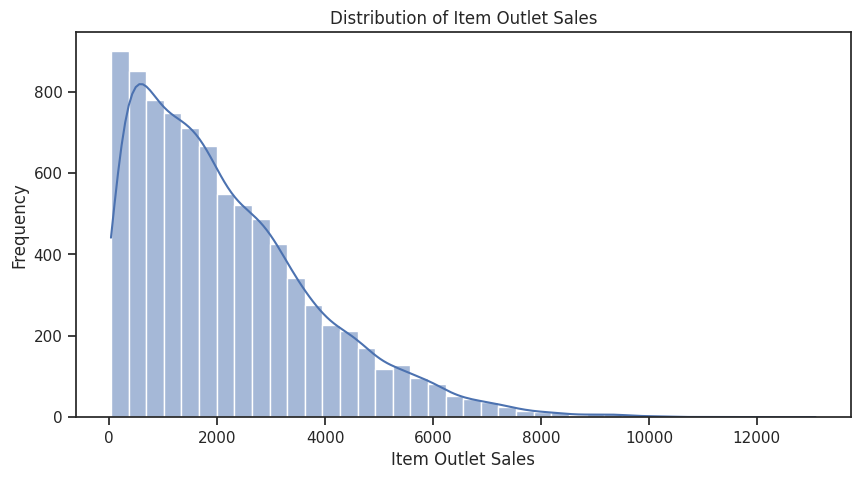

In [66]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data["Item_Outlet_Sales"],
    bins=40,
    kde=True
)

plt.title("Distribution of Item Outlet Sales")
plt.xlabel("Item Outlet Sales")
plt.ylabel("Frequency")

plt.show()

In [67]:
print("Average Sales:", round(data["Item_Outlet_Sales"].mean(), 2))
print("Median Sales:", round(data["Item_Outlet_Sales"].median(), 2))
print("Maximum Sales:", round(data["Item_Outlet_Sales"].max(), 2))
print("Minimum Sales:", round(data["Item_Outlet_Sales"].min(), 2))

Average Sales: 2181.29
Median Sales: 1794.33
Maximum Sales: 13086.96
Minimum Sales: 33.29


In [68]:
sales_by_item = (
    data.groupby("Item_Type")["Item_Outlet_Sales"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

display(sales_by_item)

,sum,mean,count
Item_Type,,,
Fruits and Vegetables,2.820060e+06,2289.009592,1232
Snack Foods,2.732786e+06,2277.321739,1200
Household,2.055494e+06,2258.784300,910
Frozen Foods,1.825735e+06,2132.867744,856
Dairy,1.522594e+06,2232.542597,682
Canned,1.444151e+06,2225.194904,649
Baking Goods,1.265525e+06,1952.971207,648
Health and Hygiene,1.045200e+06,2010.000265,520
Meat,9.175656e+05,2158.977911,425


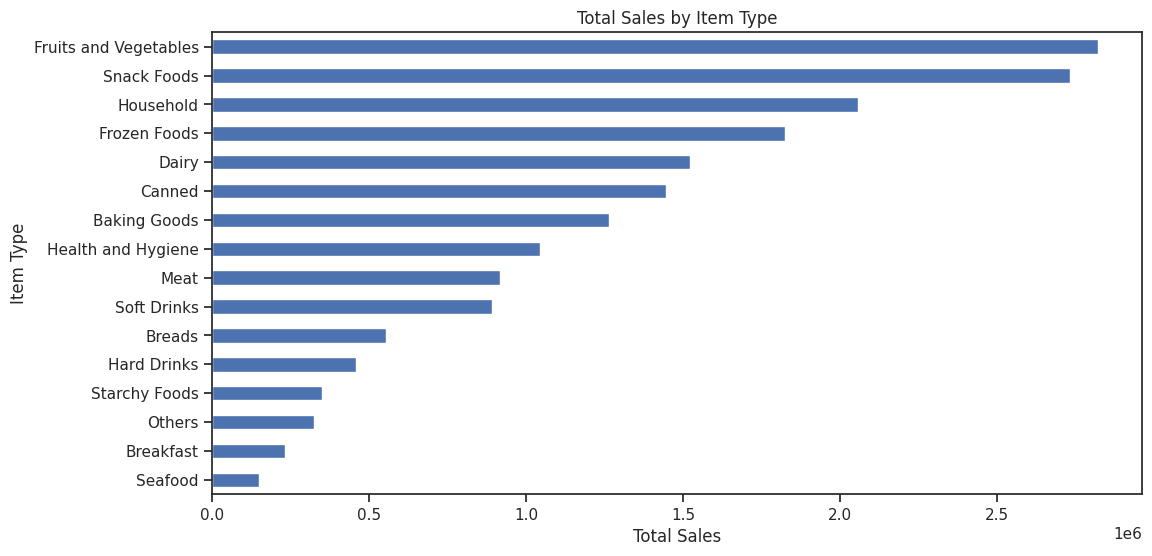

In [69]:
#visual
plt.figure(figsize=(12, 6))

sales_by_item["sum"].sort_values().plot(kind="barh")

plt.title("Total Sales by Item Type")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")

plt.show()

In [70]:
outlet_sales = (
    data.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .agg(["sum", "mean", "count"])
    .sort_values("sum", ascending=False)
)

display(outlet_sales)

,sum,mean,count
Outlet_Type,,,
Supermarket Type1,1.291734e+07,2316.181148,5577
Supermarket Type3,3.453926e+06,3694.038558,935
Supermarket Type2,1.851823e+06,1995.498739,928
Grocery Store,3.680343e+05,339.828500,1083


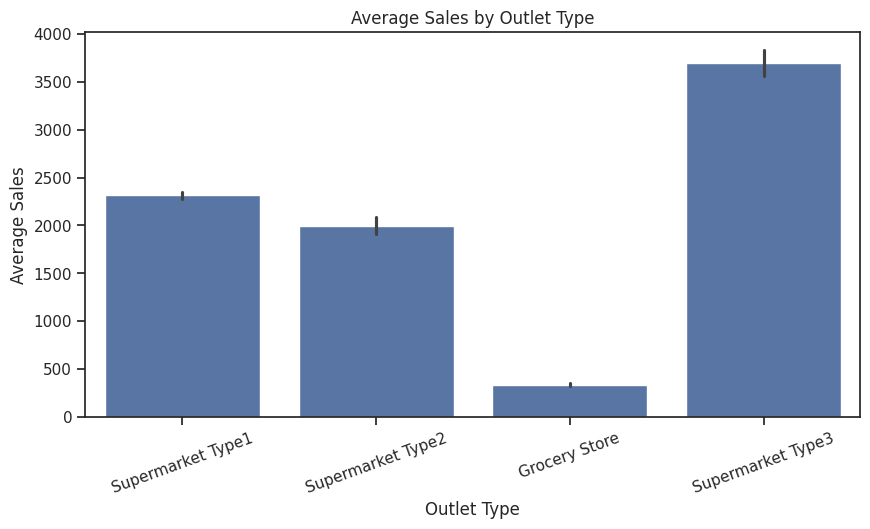

In [71]:
#plot visuals
plt.figure(figsize=(10, 5))

sns.barplot(
    data=data,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    estimator=np.mean
)

plt.title("Average Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Average Sales")

plt.xticks(rotation=20)
plt.show()

In [72]:
location_sales = (
    data.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)

display(location_sales)

,sum,mean
Outlet_Location_Type,,
Tier 3,7.636753e+06,2279.627651
Tier 2,6.472314e+06,2323.990559
Tier 1,4.482059e+06,1876.909159


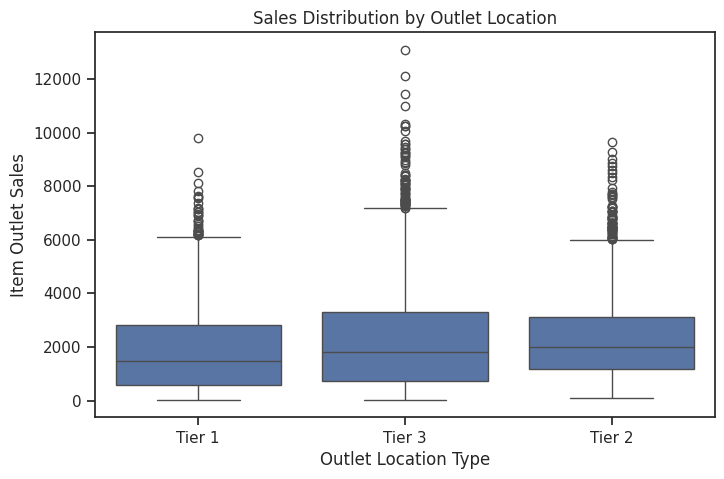

In [73]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="Outlet_Location_Type",
    y="Item_Outlet_Sales"
)

plt.title("Sales Distribution by Outlet Location")
plt.xlabel("Outlet Location Type")
plt.ylabel("Item Outlet Sales")

plt.show()

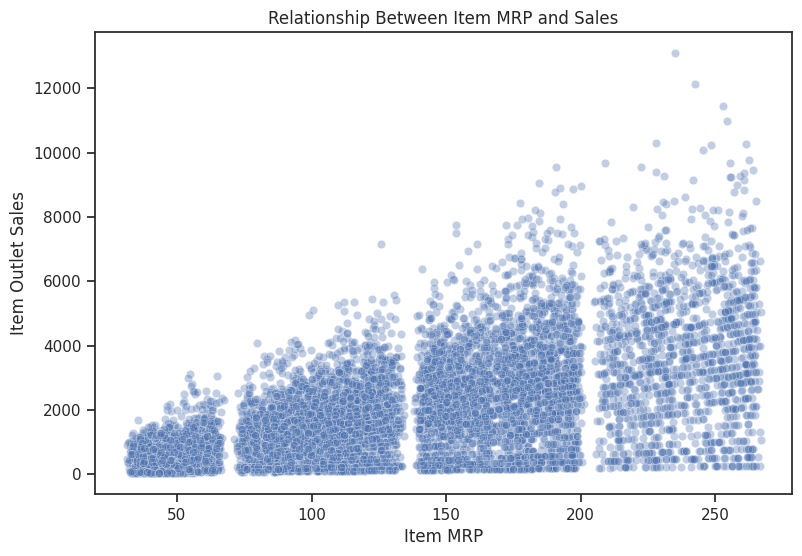

In [74]:
#imp numerical vs relationship
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="Item_MRP",
    y="Item_Outlet_Sales",
    alpha=0.35
)

plt.title("Relationship Between Item MRP and Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.show()

In [75]:
#correlation heatmp
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
numeric_columns = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Age",
    "Item_Outlet_Sales"
]

correlation = data[numeric_columns].corr()

display(correlation)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Age,Item_Outlet_Sales
Item_Weight,1.000000,-0.009187,0.025986,0.013383,0.013162
Item_Visibility,-0.009187,1.000000,-0.001315,0.074834,-0.128625
Item_MRP,0.025986,-0.001315,1.000000,-0.005020,0.567574
Outlet_Age,0.013383,0.074834,-0.005020,1.000000,0.049135
Item_Outlet_Sales,0.013162,-0.128625,0.567574,0.049135,1.000000


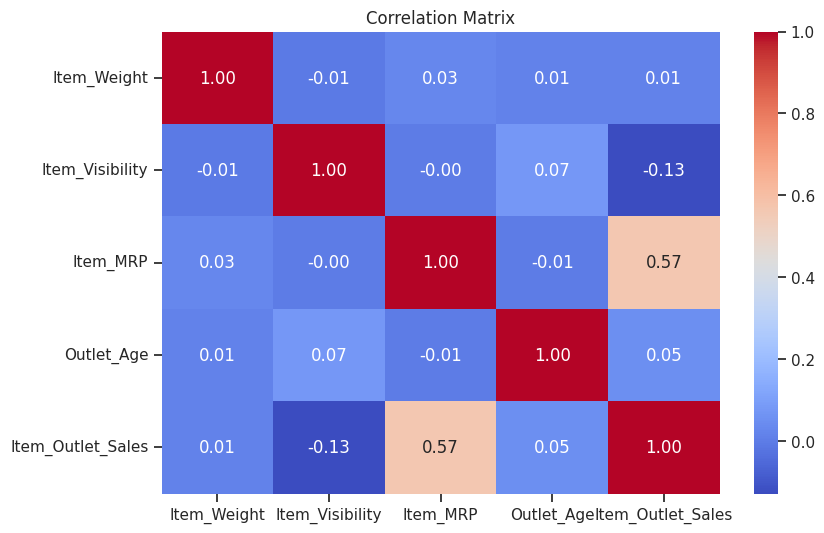

In [77]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [78]:
#business analysis which sector performs good?
outlet_performance = (
    data.groupby("Outlet_Identifier")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Average_Sales=("Item_Outlet_Sales", "mean"),
        Number_of_Items=("Item_Identifier", "count"),
        Outlet_Type=("Outlet_Type", "first"),
        Location=("Outlet_Location_Type", "first")
    )
    .sort_values("Total_Sales", ascending=False)
)

display(outlet_performance)

,Total_Sales,Average_Sales,Number_of_Items,Outlet_Type,Location
Outlet_Identifier,,,,,
OUT027,3.453926e+06,3694.038558,935,Supermarket Type3,Tier 3
OUT035,2.268123e+06,2438.841866,930,Supermarket Type1,Tier 2
OUT049,2.183970e+06,2348.354635,930,Supermarket Type1,Tier 1
OUT017,2.167465e+06,2340.675263,926,Supermarket Type1,Tier 2
OUT013,2.142664e+06,2298.995256,932,Supermarket Type1,Tier 3
OUT046,2.118395e+06,2277.844267,930,Supermarket Type1,Tier 1
OUT045,2.036725e+06,2192.384798,929,Supermarket Type1,Tier 2
OUT018,1.851823e+06,1995.498739,928,Supermarket Type2,Tier 3
OUT010,1.883402e+05,339.351662,555,Grocery Store,Tier 3


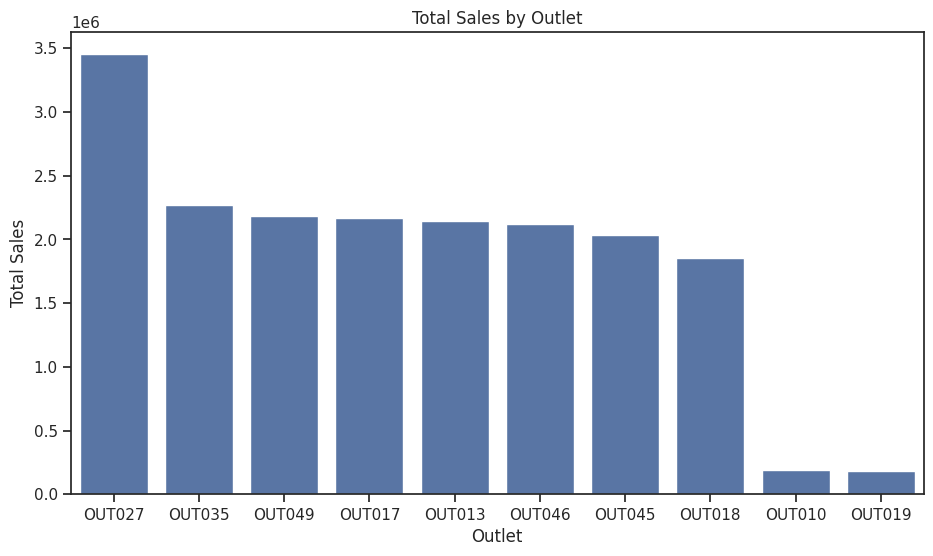

In [79]:
#visual answer
plt.figure(figsize=(11, 6))

sns.barplot(
    data=outlet_performance.reset_index(),
    x="Outlet_Identifier",
    y="Total_Sales"
)

plt.title("Total Sales by Outlet")
plt.xlabel("Outlet")
plt.ylabel("Total Sales")

plt.show()

In [80]:
#ml data preparation
X = data.drop(columns=["Item_Outlet_Sales"])
y = data["Item_Outlet_Sales"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (8523, 16)
Target: (8523,)


In [81]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", X_train.shape[0])
print("Validation records:", X_valid.shape[0])

Training records: 6818
Validation records: 1705


In [83]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Unnamed: 0', 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Outlet_Age', 'Item_Visibility_Pct']

Categorical Features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'MRP_Category', 'Item_Category_Code']


In [85]:
#piplinig  process
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [86]:
#linear regresion
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_valid)

linear_mae = mean_absolute_error(
    y_valid,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(y_valid, linear_predictions)
)

linear_r2 = r2_score(
    y_valid,
    linear_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 944.97
RMSE: 1273.91
R²  : 0.4029


In [87]:
#model- Random forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_valid)

rf_mae = mean_absolute_error(
    y_valid,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(y_valid, rf_predictions)
)

rf_r2 = r2_score(
    y_valid,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 724.07
RMSE: 1041.58
R²  : 0.6008


In [88]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_valid)

gb_mae = mean_absolute_error(
    y_valid,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(y_valid, gb_predictions)
)

gb_r2 = r2_score(
    y_valid,
    gb_predictions
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Results
-------------------------
MAE : 732.87
RMSE: 1045.31
R²  : 0.598


In [89]:
#data models comparision
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2_Score": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_results = model_results.sort_values(
    "R2_Score",
    ascending=False
)

display(model_results)

,Model,MAE,RMSE,R2_Score
1,Random Forest,724.066122,1041.576010,0.600849
2,Gradient Boosting,732.871451,1045.312434,0.597980
0,Linear Regression,944.968637,1273.911377,0.402918


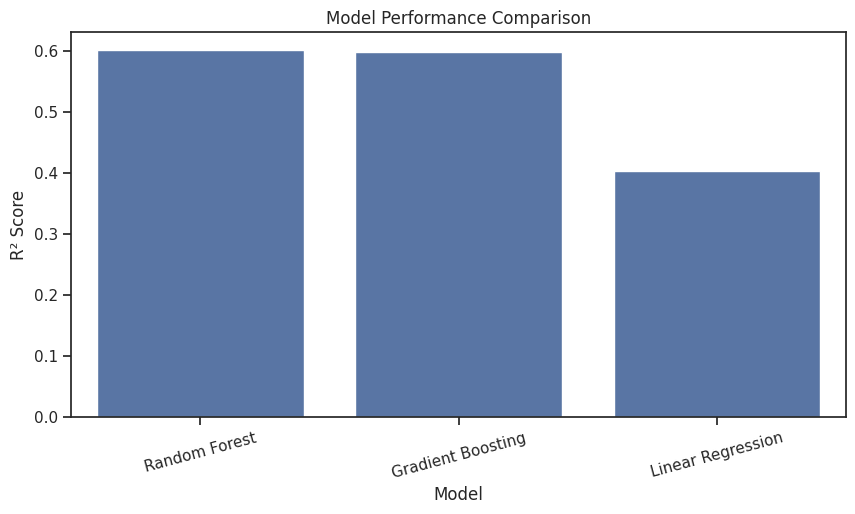

In [90]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2_Score"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)
plt.show()

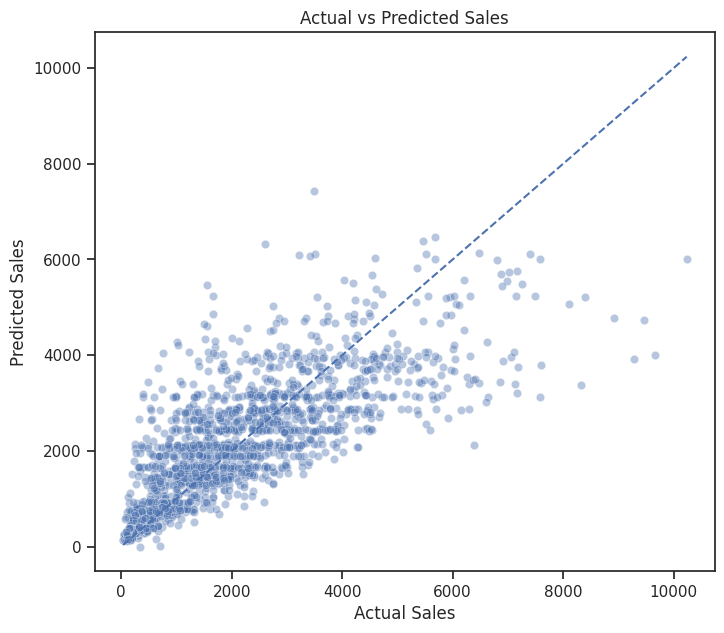

In [91]:
best_model = gb_model

best_predictions = best_model.predict(X_valid)

plt.figure(figsize=(8, 7))

sns.scatterplot(
    x=y_valid,
    y=best_predictions,
    alpha=0.4
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

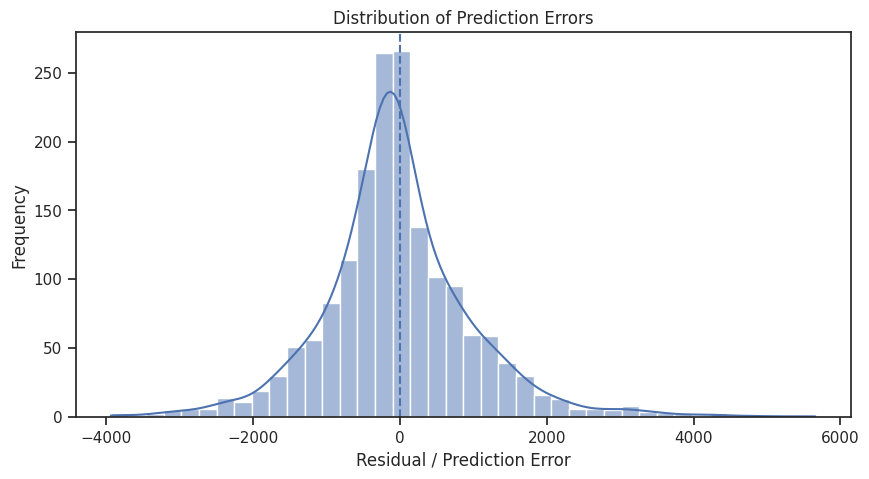

In [92]:
residuals = y_valid - best_predictions

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual / Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [93]:
# Get transformed feature names
feature_names = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance from Gradient Boosting
importance_values = (
    best_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
3,num__Item_MRP,0.512156
1596,cat__Outlet_Type_Grocery Store,0.296163
4,num__Outlet_Establishment_Year,0.038536
5,num__Outlet_Age,0.036058
1585,cat__Outlet_Identifier_OUT027,0.027826
1599,cat__Outlet_Type_Supermarket Type3,0.021297
1597,cat__Outlet_Type_Supermarket Type1,0.004714
0,num__Unnamed: 0,0.003717
1313,cat__Item_Identifier_NCE42,0.002713
6,num__Item_Visibility_Pct,0.002357


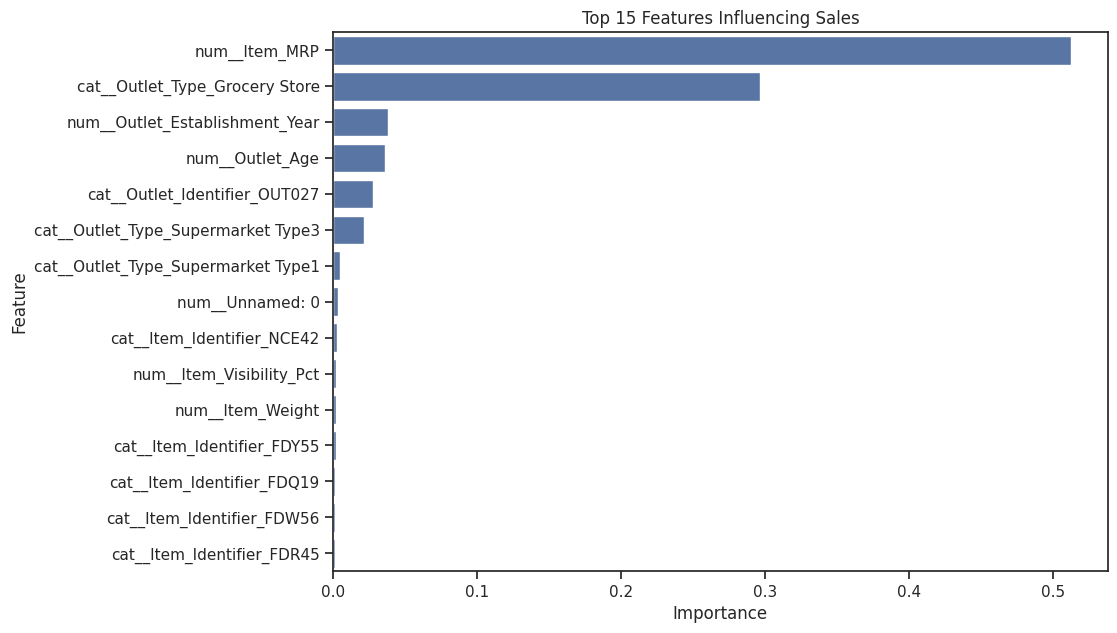

In [94]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Sales")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

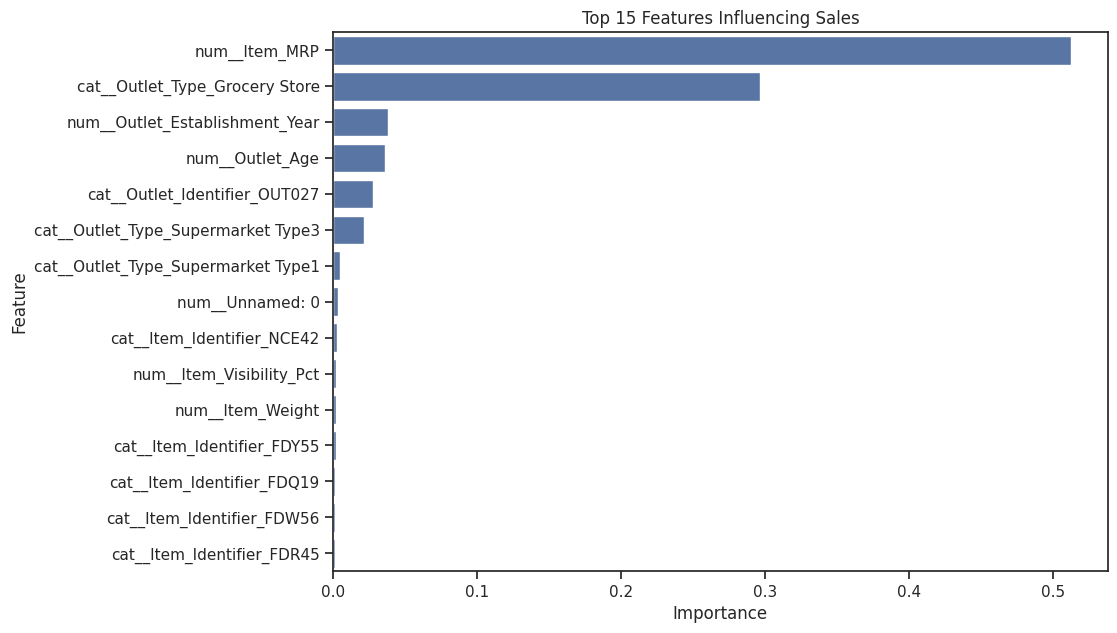

In [95]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Sales")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()